Homework 2
==========
<link rel="stylesheet" href="/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/02_Script/02_1_Function/styles.css">

>📌 Question 2.2.1
> Using the same data set (credit_card_data.txt or credit_card_data-headers.txt) as in Question 2.2, use the ksvm or kknn function to find a good classifier:
>> - _a._ using cross-validation (do this for the k-nearest-neighbors model; SVM is optional); and
>> - _b._ splitting the data into training, validation, and test data sets (pick either KNN or SVM; the other is optional).


<link rel="stylesheet" href="/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/02_Script/02_1_Function/styles.css">

> - #### _a._ using cross-validation (do this for the k-nearest-neighbors model; SVM is optional).

[1] 0.8425076

  k_value  Accuracy     kernel kfoldsval
1      13 0.8593272 triangular         5
2      15 0.8593272    optimal        10


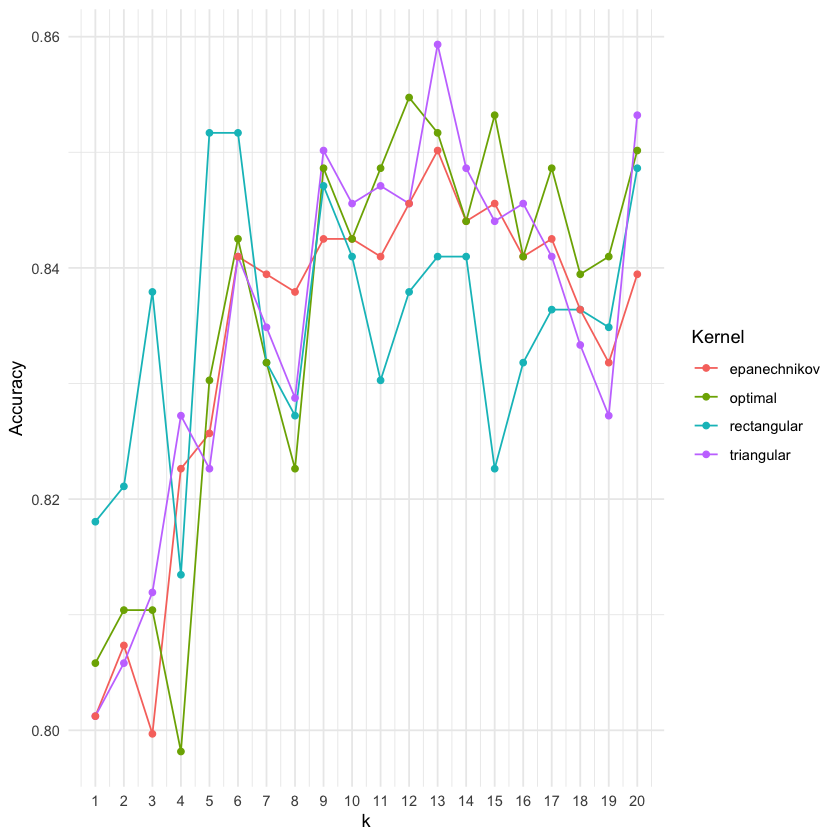

In [ ]:
library("kernlab")
library("kknn")
library("tidyr")
library("dplyr")
library("ggplot2")
library("plotly")
library("combinat")

rm(list = ls())
# Load Data Shared with the credit card applications
set.seed(1234)
data_path<- "/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/Homework2_ISYE6501/data 3.1/credit_card_data-headers.txt"

Credit_Card_Data <- read.table(data_path, sep = "\t", header = TRUE)

#Convert the target variable to a factor
Credit_Card_Data[,11] <- as.factor(Credit_Card_Data[,11])

# Perform k-fold cross-validation using kknn
train_kfold <- cv.kknn(formula =R1 ~ ., data = Credit_Card_Data, kcv = 15,k=7, scale = TRUE,kernel="optimal")

train_fit <- train.kknn(formula = R1 ~ ., data =Credit_Card_Data , kmax = 20, kernel = c("rectangular", "triangular", "epanechnikov", "optimal"))


Confusion_matrix<-train_kfold[[1]]
accuracy <- mean(Confusion_matrix[,1] == Confusion_matrix[,2])
accuracy



#create function that save all the 

cv_results <- function(data, k_folds, k_value, kernel_type) {
  train_kfold <- cv.kknn(formula = R1 ~ ., data = data, kcv = k_folds, k = k_value, scale = TRUE, kernel = kernel_type)
  Confusion_matrix <- train_kfold[[1]]
  accuracy <- mean(Confusion_matrix[,1] == Confusion_matrix[,2])
  return(accuracy)
}

# Example of using the function

df <- data.frame(
  k_value    = integer(),
  Accuracy  = numeric(),
  kernel = character(),
  kfoldsval= integer(),
  stringsAsFactors = FALSE  # optional in modern R
)

for (k in 1:20) {
  for (kernel in c("rectangular", "triangular", "epanechnikov", "optimal")) {
    for(folds in c(5,7,10)){
      acc <- cv_results(Credit_Card_Data, k_folds = folds, k_value = k, kernel_type = kernel)
      df <- rbind(df, data.frame(k_value = k, Accuracy = acc, kernel = kernel, kfoldsval=folds)) 
    } 
  }
}

df_max_accuracy<-df[df$Accuracy==max(df$Accuracy),] #Filter the max accuracy
rownames(df_max_accuracy) <- NULL #reset row names


df2 <- df[df$kfoldsval==df_max_accuracy[1,4],]

print(df_max_accuracy)    # print the max accuracy dataframe      

# Plotting the results
  ggplot(df2, aes(x = k_value, y = Accuracy, color = kernel)) +
   geom_line() +
   geom_point() +
    scale_x_continuous(breaks = sort(unique(df2$k_value))) +
   labs(x = "k", y = "Accuracy", color = "Kernel") +
   theme_minimal()


<link rel="stylesheet" href="/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/02_Script/02_1_Function/styles.css">

> - #### _b._ splitting the data into training, validation, and test data sets (pick either KNN or SVM; the other is optional).

In [ ]:
# Split the data into training (60%), validation (20%), and testing (20%) sets
set.seed(123)
n<-nrow(Credit_Card_Data) #number of Data points
samplerows <- sample(1:n) 

#split the data in training, validation and testing

samplerows_train <- sample(1:length(samplerows), size = round(0.6*length(samplerows)))     #randomly sample 60% of the data for training

train_data <- Credit_Card_Data[1:round(0.60*n), ] #training data

valida_data <- Credit_Card_Data[(round(0.60*n)+1):round(0.80*n), ] #validation data
test_data <- Credit_Card_Data[(round(0.80*n)+1):n, ] #testing data

kknn_training <- function(train_dataset,valid_data, k_value, kernel_type) {
  train_kfold <- kknn(formula = R1 ~ ., 
          train = train_dataset, test = valid_data, k = k_value, scale = TRUE, kernel = kernel_type)
   y_pred <- fitted(train_kfold)                 # same as fit$fitted.values

  # true labels from validation data
  y_true <- valid_data$R1

  # confusion matrix
  Confusion_matrix <- table(True = y_true, Pred = y_pred)

  # overall accuracy
  accuracy <- mean(y_true == y_pred)

  return( accuracy)
}


df_b_valid <- data.frame(
  k_value    = integer(),
  Accuracy  = numeric(),
  kernel = character(),
  stringsAsFactors = FALSE  # optional in modern R
)




df_b_test <- data.frame(
  k_value    = integer(),
  Accuracy  = numeric(),
  kernel = character(),
  stringsAsFactors = FALSE  # optional in modern R
)


for (k in 1:20) {
  for (kernel in c("rectangular", "triangular", "epanechnikov", "optimal")) {
      acc <- kknn_training(train_dataset=train_data, valid_data= valida_data, k_value = k, kernel_type = kernel)
     df_b_valid <- rbind(df_b_valid, data.frame(k_value = k, Accuracy = acc, kernel = kernel)) 
  }
}

for (k in 1:20) {
  for (kernel in c("rectangular", "triangular", "epanechnikov", "optimal")) {
      acc <- kknn_training(train_dataset=train_data, valid_data= test_data, k_value = k, kernel_type = kernel)
     df_b_test <- rbind(df_b_test, data.frame(k_value = k, Accuracy = acc, kernel = kernel)) 
  }
}

print("---------- VALIDATION DATASET RESULTS -------------")

df_b_max_accuracy_val<-df_b_valid[df_b_valid$Accuracy==max(df_b_valid$Accuracy),] #Filter the max accuracy
df_b_max_accuracy_val

print("---------- TEST DATASET RESULTS -------------")

df_b_max_accuracy_test<-df_b_test[df_b_test$Accuracy==max(df_b_test$Accuracy),] #Filter the max accuracy
df_b_max_accuracy_test

[1] "---------- VALIDATION DATASET RESULTS -------------"


,k_value,Accuracy,kernel
,<int>,<dbl>,<chr>
40,10,0.8549618,optimal


[1] "---------- TEST DATASET RESULTS -------------"


,k_value,Accuracy,kernel
,<int>,<dbl>,<chr>
76,19,0.9465649,optimal
80,20,0.9465649,optimal


<link rel="stylesheet" href="/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/02_Script/02_1_Function/styles.css">

>📌Question 4.2
>>The iris data set iris.txt contains 150 data points, each with four predictor variables and one categorical response. The predictors are the width and length of the sepal and petal of flowers and the response is the type of flower. The data is available from the R library datasets and can be accessed with iris once the library is loaded. It is also available at the UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/Iris ). The response values are only given to see how well a specific method performed and should not be used to build the model.
>>Use the R function kmeans to cluster the points as well as possible. Report the best combination of predictors, your suggested value of k, and how well your best clustering predicts flower type.


In [12]:
data(iris)                 # iris in datasets
iris_x <- iris[, 1:4]      # predictors only
species <- iris$Species    # keep for evaluation only



km_all_3 <- kmeans(iris_x, centers = 3, nstart = 30)

tab <- table(km_all_3$cluster, species)
score <- sum(apply(tab, 1, max)) / nrow(iris)

score

predictor_names <- colnames(iris_x)
best <- NULL

results_kmeans_model <- data.frame(
  k  = integer(),
  p  = integer(),
  predictors = character(),
  score = numeric(),
  stringsAsFactors = FALSE
)



j=1
for(p in 1:length(predictor_names)) {
    combs <- combn(predictor_names, p, simplify = FALSE) # generate all combinations of predictors of size p # nolint
    for(c in combs) {
      for(k in 2:10){
        km <- kmeans(iris_x[, c], centers = k, nstart = 25) # run k-means with the selected predictors
        tab <- table(km$cluster, species) # confusion matrix
        score <- sum(apply(tab, 1, max)) / nrow(iris) # calculate the score
        results_kmeans_model[j, ] <- list(
        k = k,
        p = length(c),
        predictors = paste(c, collapse = ","),
        score = score
      )
    j=j+1
        if(is.null(best) || score > best$score) {     # check if the combination of fields is null and check if the currect score is better than the best score
            best <- list(predictors = c, score = score,k_val=k) # save the best predictors and score
        }
        }
    }
}

best

results_kmeans_model_best_k<-results_kmeans_model[results_kmeans_model$k==best$k_val,]




[1] 0.8933333

$predictors
[1] "Sepal.Length" "Petal.Length" "Petal.Width" 

$score
[1] 0.98

$k_val
[1] 6